# MLOps Training & Modelling

Two PyCaret pipelines built from the same dataset

1. **Regression** — predicting `burnout_score` (continuous severity)
2. **Classification** — predicting `seeks_professional_help` (binary)


In [34]:
import pandas as pd
import numpy as np
import mlflow
from mlflow.tracking import MlflowClient

df = pd.read_csv("mlops dataset/tech_mental_health_burnout.csv")

### Why *burnout_score* Instead of burnout_level?

This dataset's documented targets are `burnout_level` (Low/Moderate/High classification) and
`seeks_professional_help` (binary). This pipeline predicts the continuous `burnout_score`
**instead of** `burnout_level`, because the distribution of `burnout_level` is severely imbalanced:

| Class | Count | % |
|---|---|---|
| Low | 131,620 | 87.7% |
| Moderate | 18,315 | 12.2% |
| High | 65 | 0.043% |

With a 70/30 train/test split, the test set would have only around 20 High-burnout cases out of 45,000 rows. With so few examples, the model would struggle to properly learn the High-burnout class. Accuracy could still be above 99%, but this would be misleading because the model could perform poorly on the class we actually care about.

SMOTE would not fully solve the problem either. With only around 45 real High-burnout cases in the training set, it can only create synthetic examples based on those existing cases. It cannot add new information. The results may therefore be unstable, especially with 10-fold cross-validation, where each fold would contain only 4–5 real High-burnout cases. This means F1 and recall could change significantly depending on which cases fall into each fold. 

SMOTE can still be applied, and PyCaret runs it successfully, but the resulting model performance should be treated with caution and may not be reliable enough to report as a strong result.

In [ ]:
from pycaret.regression import *

DROP_FEATURES = [
    "age", "experience_years", "meetings_per_day", "deadlines_missed", "caffeine_intake",
    "gender", "job_role", "company_size", "work_mode", "physical_activity_days",
    "screen_time_hours", "social_support_score"
]

reg_setup = setup(
    data=df,
    target='burnout_score',
    ignore_features=['burnout_level']+ DROP_FEATURES,
    normalize=True,
    normalize_method='zscore',
    transformation=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    log_experiment=True,
    experiment_name='burnout_monitoring_v1',
    log_plots=True,

    session_id=123
)


,Description,Value
0,Session id,123
1,Target,burnout_score
2,Target type,Regression
3,Original data shape,"(150000, 25)"
4,Transformed data shape,"(150000, 12)"
5,Transformed train set shape,"(105000, 12)"
6,Transformed test set shape,"(45000, 12)"
7,Ignore features,14
8,Numeric features,11
9,Preprocess,True


In [35]:
best_model = compare_models(sort='RMSE')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,0.3761,0.2595,0.5094,0.7905,0.1568,0.1938,0.3050
gbr,Gradient Boosting Regressor,0.3883,0.2635,0.5134,0.7873,0.1595,0.2065,1.9280
et,Extra Trees Regressor,0.3826,0.2657,0.5155,0.7855,0.1590,0.1994,4.7050
rf,Random Forest Regressor,0.3831,0.2671,0.5168,0.7844,0.1595,0.1994,6.7900
knn,K Neighbors Regressor,0.4075,0.3101,0.5569,0.7497,0.1709,0.2075,1.3990
lar,Least Angle Regression,0.4542,0.3253,0.5703,0.7375,0.1978,0.2754,0.1550
br,Bayesian Ridge,0.4542,0.3253,0.5703,0.7375,0.1978,0.2754,0.1530
lr,Linear Regression,0.4542,0.3253,0.5703,0.7375,0.1978,0.2754,0.7120
ridge,Ridge Regression,0.4542,0.3253,0.5703,0.7375,0.1978,0.2754,0.4400
huber,Huber Regressor,0.4535,0.3258,0.5708,0.7370,0.1978,0.2731,0.1910


2026/08/19 07:09:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:09:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:09:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:09:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:09:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:09:57 

XGBoost performed best with an RMSE of 0.5094. The four best models were all tree-based, while the linear models had a slightly higher RMSE of around 0.57. This suggests that the relationship is mostly linear, but tree-based models can capture some additional patterns that improve predictions slightly.

In [36]:
tuned_model = tune_model(
    best_model,
    n_iter=15,
    fold=5,
    optimize='RMSE',
    choose_better=True   
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3895,0.3015,0.5491,0.7561,0.1660,0.1749
1,0.3926,0.3066,0.5537,0.7553,0.1675,0.1755
2,0.3887,0.2997,0.5475,0.7588,0.1662,0.1763
3,0.3865,0.2985,0.5464,0.7565,0.1652,0.1752
4,0.3902,0.2991,0.5469,0.7586,0.1666,0.1792
Mean,0.3895,0.3011,0.5487,0.7570,0.1663,0.1762
Std,0.0020,0.0029,0.0027,0.0014,0.0008,0.0015


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


2026/08/19 07:11:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


**Why RMSE**: RMSE gives more weight to larger errors. Since burnout_score is right-skewed, with most employees scoring around 1–2 and fewer scoring 7–8, this helps place more importance on accurately predicting employees with higher burnout. MAE is also included to show the typical prediction error in a simpler way. This is important because the main purpose of a burnout-monitoring tool is to identify employees at risk of serious burnout, rather than simply performing well on the majority with low scores. MAE is also included to show the typical prediction error, but it treats all errors proportionally the same, so it may not penalize large mistakes enough.

Tuning did not improve on the default XGBoost model, so the original configuration was kept. This supports the earlier finding that the relationship is mostly linear, meaning there was limited extra structure for tuning to improve. The default model was already performing well without adding unnecessary complexity.

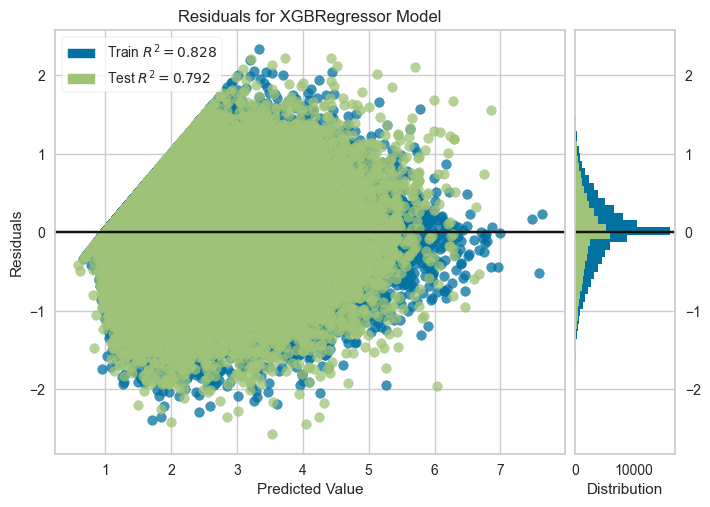

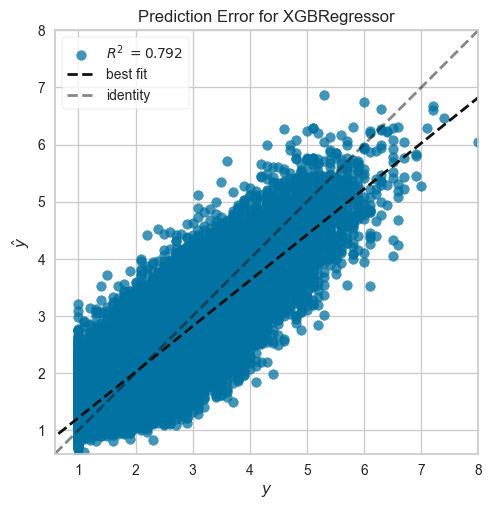

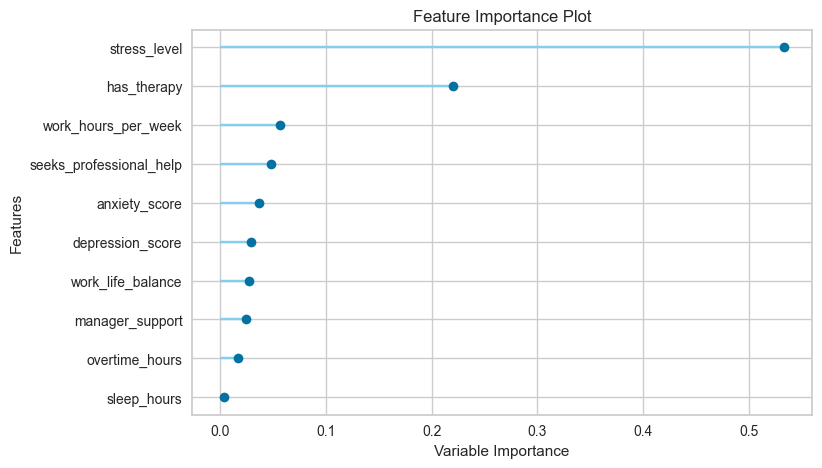

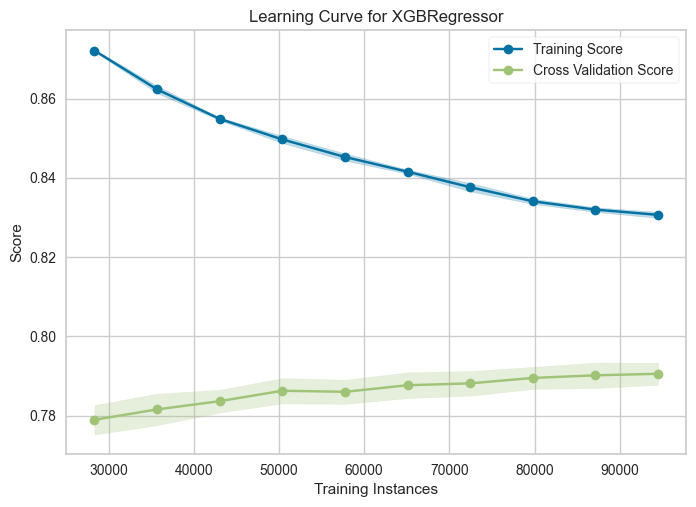

In [37]:
plot_model(tuned_model, plot='residuals')
plot_model(tuned_model, plot='error')
plot_model(tuned_model, plot='feature')  
plot_model(tuned_model, plot='learning')

`stress_level` is the most important feature, which matches its strong correlation with burnout (0.75). Interestingly, `has_therapy` ranks second, ahead of anxiety and depression scores, suggesting that XGBoost may be capturing an interaction between therapy status and other factors that simple correlation does not show.

In [38]:
evaluate_model(tuned_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [39]:
holdout_pred = predict_model(tuned_model)

holdout_pred['error'] = holdout_pred['prediction_label'] - holdout_pred['burnout_score']
holdout_pred['abs_error'] = holdout_pred['error'].abs()

print("Overall MAE on holdout:", holdout_pred['abs_error'].mean())

holdout_pred['band'] = pd.cut(
    holdout_pred['burnout_score'],
    bins=[0, 2, 4, 10],
    labels=['Low (<=2)', 'Moderate (2-4)', 'High (>4)']
)
print("\nMean absolute error by severity band:")
print(holdout_pred.groupby('band')['abs_error'].mean())

high_burnout = holdout_pred[holdout_pred['burnout_score'] > 4]
underestimated = high_burnout[high_burnout['error'] < 0]
print(f"\n{len(underestimated)} of {len(high_burnout)} High-burnout holdout cases were underestimated.")

Overall MAE on holdout: 0.37406167

Mean absolute error by severity band:
band
Low (<=2)         0.278517
Moderate (2-4)    0.467274
High (>4)         0.627920
Name: abs_error, dtype: float32

2402 of 2981 High-burnout holdout cases were underestimated.


Prediction error increases as burnout severity increases, with MAE rising from 0.28 for Low, to 0.47 for Moderate, and 0.63 for High burnout. More importantly, 80.5% of High-burnout cases were underestimated, meaning the model tends to predict lower burnout scores for the employees who need the most attention. This is likely influenced by the large number of low-burnout cases in the dataset and is an important limitation if the model were used for real-world monitoring.

In [40]:
final_model = finalize_model(tuned_model)

2026/08/19 07:11:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [41]:
new_data = df.sample(5, random_state=99)

unseen_pred = predict_model(
    final_model,
    data=new_data.drop(columns=['burnout_score', 'burnout_level'])
)

unseen_pred['actual'] = new_data['burnout_score'].values
unseen_pred['error'] = unseen_pred['prediction_label'] - unseen_pred['actual']

print(unseen_pred[
    ['job_role', 'stress_level', 'work_hours_per_week',
     'actual', 'prediction_label', 'error']
])

                job_role  stress_level  work_hours_per_week  actual  \
5944         ML Engineer           6.1                 31.0     1.8   
22474             DevOps           6.9                 57.0     3.8   
93149    Product Manager           5.5                 50.0     1.2   
91262        ML Engineer           4.8                 49.0     1.0   
58794  Software Engineer           5.7                 52.0     2.3   

       prediction_label     error  
5944           1.583357 -0.216643  
22474          3.968843  0.168843  
93149          2.566601  1.366601  
91262          1.102065  0.102065  
58794          2.657107  0.357107  


In [42]:
save_model(final_model, 'burnout_score_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['work_hours_per_week',
                                              'overtime_hours',
                                              'job_satisfaction',
                                              'manager_support',
                                              'work_life_balance', 'sleep_hours',
                                              'has_therapy', 'stress_level',
                                              'anxiety_score',
                                              'depression_score',
                                              'seeks_professional_help'],
                                     transformer=SimpleImputer(add_indicator=Fa...
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_cons

In [43]:
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name('burnout_monitoring_v1')

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.RMSE ASC"]
)
best_run = runs[0]
print("Best run ID:", best_run.info.run_id)
print("Best run RMSE:", best_run.data.metrics.get('RMSE'))
print("Best run R2:", best_run.data.metrics.get('R2'))

model_uri = f"runs:/{best_run.info.run_id}/model"
registered_model = mlflow.register_model(model_uri=model_uri, name="burnout_score_predictor")
print(f"\nRegistered: {registered_model.name} v{registered_model.version}")

client.transition_model_version_stage(
    name="burnout_score_predictor",
    version=registered_model.version,
    stage="Staging"
)

Best run ID: 91326beac7de44dba3bc8d3f83c2c618
Best run RMSE: 0.5094
Best run R2: 0.7905

Registered: burnout_score_predictor v3


Registered model 'burnout_score_predictor' already exists. Creating a new version of this model...
Created version '3' of model 'burnout_score_predictor'.


<ModelVersion: aliases=[], creation_timestamp=1787094699374, current_stage='Staging', description=None, last_updated_timestamp=1787094699411, name='burnout_score_predictor', run_id='91326beac7de44dba3bc8d3f83c2c618', run_link=None, source='file:///c:/Users/evan/Downloads/mlops%20assignment/mlruns/985871195327816667/91326beac7de44dba3bc8d3f83c2c618/artifacts/model', status='READY', status_message=None, tags={}, user_id=None, version=3>

The model is registered under Staging rather than Production because it still needs to be validated before being used for live predictions. This follows standard MLOps practice, where a new model is tested first before being promoted to production.

In [44]:
loaded_pipeline = load_model('burnout_score_pipeline')
sample_input = df.drop(columns=['burnout_score', 'burnout_level']).sample(3, random_state=1)
predict_model(loaded_pipeline, data=sample_input)[['prediction_label']]

Transformation Pipeline and Model Successfully Loaded


,prediction_label
58397,1.164797
108538,3.297013
149880,1.719233


### Part 2: Classification Pipeline, predicting seeks_professional_help

Class balance: 135,550 employees (90.4%) did not seek professional help, while 14,450 (9.6%) did. This is a noticeable but manageable imbalance and is much less severe than the High burnout class, which made up only around 0.04% of the data. Therefore, using `fix_imbalance=True` in PyCaret is appropriate, with no need to exclude the target from modelling.

Leakage Check on `has_therapy`:

| | seeks_professional_help = 0 | seeks_professional_help = 1 | Rate |
|---|---|---|---|
| has_therapy = 0 | 100,927 | 11,403 | 10.1% |
| has_therapy = 1 | 34,623 | 3,047 | 8.1% |

**Correlation**: The correlation is -0.03, which is negligible. Employees already in therapy are slightly less likely to be flagged as seeking professional help, suggesting the target is not simply duplicating therapy status. Therefore, has_therapy is kept as a feature.

**Other features**: burnout_score and burnout_level are also kept because they can reasonably help predict whether someone seeks professional help and are not derived from the target.

In [45]:
from pycaret.classification import *

clf_setup = setup(
    data=df,
    target='seeks_professional_help',
    ignore_features=DROP_FEATURES,
    normalize=True,
    normalize_method='zscore',
    fix_imbalance=True,   # SMOTE-based oversampling on minority class during training
    log_experiment=True,
    experiment_name='seeks_help_monitoring_v1',
    log_plots=True,

    session_id=123
)

,Description,Value
0,Session id,123
1,Target,seeks_professional_help
2,Target type,Binary
3,Original data shape,"(150000, 25)"
4,Transformed data shape,"(234770, 15)"
5,Transformed train set shape,"(189770, 15)"
6,Transformed test set shape,"(45000, 15)"
7,Ignore features,13
8,Numeric features,11
9,Categorical features,1


In [46]:
best_clf_model = compare_models(sort='F1')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.8180,0.7095,0.3948,0.2352,0.2947,0.1979,0.2067,0.1580
qda,Quadratic Discriminant Analysis,0.8154,0.6922,0.3852,0.2354,0.2869,0.1909,0.2005,0.1930
gbc,Gradient Boosting Classifier,0.8169,0.7035,0.3684,0.2252,0.2794,0.1815,0.1888,12.3540
lr,Logistic Regression,0.6740,0.7203,0.6554,0.1775,0.2793,0.1505,0.2043,0.1700
ridge,Ridge Classifier,0.6751,0.7202,0.6534,0.1776,0.2793,0.1506,0.2041,0.1510
lda,Linear Discriminant Analysis,0.6751,0.7202,0.6534,0.1776,0.2793,0.1506,0.2041,0.4460
ada,Ada Boost Classifier,0.7312,0.6934,0.5250,0.1852,0.2737,0.1530,0.1843,2.3860
svm,SVM - Linear Kernel,0.6432,0.7143,0.6797,0.1673,0.2685,0.1347,0.1929,0.2390
knn,K Neighbors Classifier,0.6909,0.6029,0.4343,0.1411,0.2130,0.0791,0.0985,5.3100
et,Extra Trees Classifier,0.8827,0.6871,0.1576,0.2959,0.2056,0.1486,0.1573,6.5610


2026/08/19 07:18:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:18:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:18:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:18:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:18:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/19 07:18:31 

Naive Bayes performs best on F1-score despite having lower accuracy (0.8180) than the tree-based models. This is because it achieves much better recall (0.41), meaning it identifies more employees who seek professional help. The tree-based models have high accuracy and precision but extremely low recall (0.01–0.03), showing that they mostly predict “no” and benefit from the 90/10 class imbalance. 

In [47]:
tuned_clf_model = tune_model(
    best_clf_model,
    n_iter=15,
    fold=5,
    optimize='F1',
    choose_better=True
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7978,0.7102,0.4572,0.2271,0.3035,0.2006,0.2174
1,0.8012,0.7109,0.4162,0.2196,0.2875,0.1846,0.1974
2,0.8023,0.7114,0.4157,0.2207,0.2883,0.1858,0.1984
3,0.8005,0.7104,0.4390,0.2252,0.2977,0.1952,0.2100
4,0.8040,0.7126,0.4370,0.2290,0.3005,0.1992,0.2133
Mean,0.8012,0.7111,0.4330,0.2243,0.2955,0.1931,0.2073
Std,0.0021,0.0009,0.0156,0.0036,0.0065,0.0067,0.0080


Fitting 5 folds for each of 15 candidates, totalling 75 fits


2026/08/19 07:18:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


**Why F1 instead of Accuracy**: with only 9.6% positive cases, a model that predicts 'no' for everyone would still achieve around 90% accuracy, but it would fail to identify anyone seeking help. F1-score is more useful here because it balances precision and recall, giving a better measure of how well the model identifies positive cases. 

In [48]:
optimized_clf = optimize_threshold(tuned_clf_model, optimize='F1')

Threshold: 0.375. F1: 0.2861
Threshold: 0.125. F1: 0.223
Threshold: 0.5. F1: 0.2963
Threshold: 0.25. F1: 0.2624
Threshold: 0.625. F1: 0.2906
Threshold: 0.75. F1: 0.2858
Threshold: 0.875. F1: 0.2833
Threshold: 0.0. F1: 0.1757
Threshold: 0.5. F1: 0.2963
Threshold: 0.5000000149011612. F1: 0.2963
Threshold: 0.21875. F1: 0.2549
Threshold: 0.09375. F1: 0.2112
Threshold: 0.3125. F1: 0.2764
Threshold: 0.1875. F1: 0.2452
Threshold: 0.34375. F1: 0.2814
Threshold: 0.4375. F1: 0.2928
Threshold: 0.46875. F1: 0.2948
Threshold: 0.5625. F1: 0.2954
Threshold: 0.59375. F1: 0.2941
Threshold: 0.6875. F1: 0.2871
Threshold: 0.71875. F1: 0.286
Threshold: 0.8125. F1: 0.2842
Threshold: 0.84375. F1: 0.284
Threshold: 0.9375. F1: 0.2641
Threshold: 0.0625. F1: 0.1977
Threshold: 0.96875. F1: 0.193
Threshold: 0.484375. F1: 0.2966
Threshold: 0.53125. F1: 0.2962
Threshold: 0.546875. F1: 0.296
Threshold: 0.609375. F1: 0.2927
Threshold: 0.671875. F1: 0.2879
Threshold: 0.78125. F1: 0.2845
Threshold: 0.03125. F1: 0.1835
T

Lowering the decision threshold from 0.5 to 0.375 increased recall and slightly improved F1 from 0.2910 to 0.2927. However, accuracy dropped a little because more employees were flagged as positive. This is a reasonable trade-off for a monitoring tool, where missing someone who may need support could be more costly than raising a few extra false alarms.

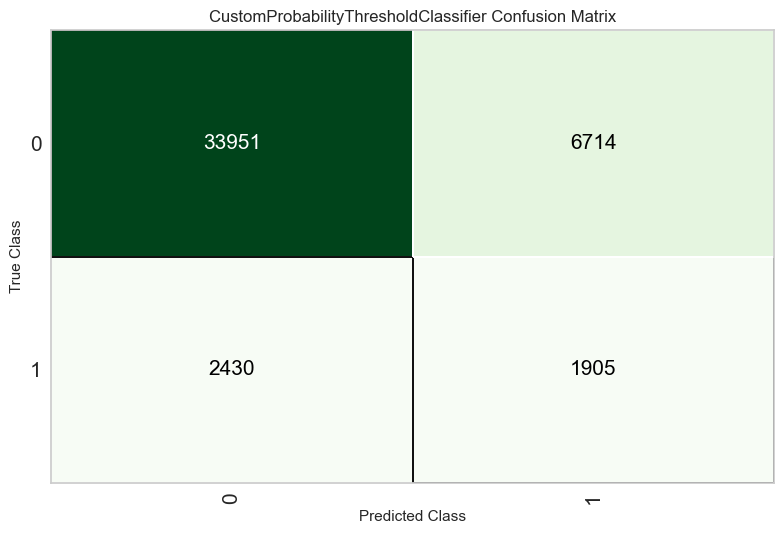

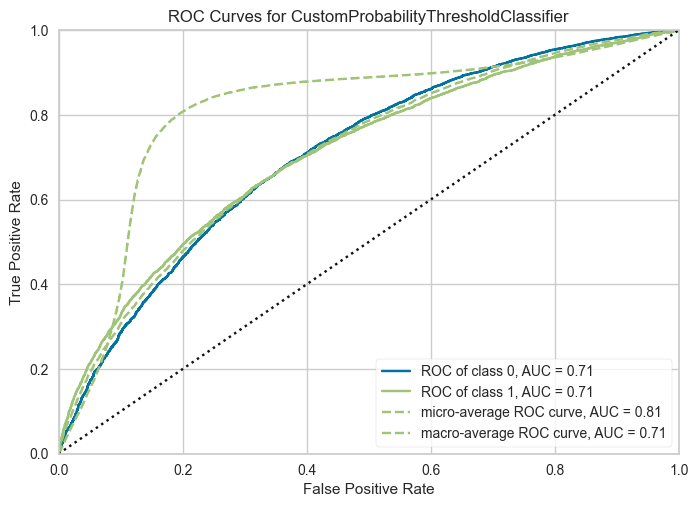

In [49]:
plot_model(optimized_clf, plot='confusion_matrix')
plot_model(optimized_clf, plot='auc')

In [50]:
evaluate_model(optimized_clf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [51]:
holdout_clf_pred = predict_model(optimized_clf)
holdout_clf_pred[['seeks_professional_help', 'prediction_label', 'prediction_score']].head(10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,0.7968,0.7103,0.4394,0.2210,0.2941,0.1903,0.2057


,seeks_professional_help,prediction_label,prediction_score
82164,0,0,0.5608
137620,0,0,0.8859
4708,0,0,0.6031
49750,0,0,0.9661
81528,0,0,0.6221
27710,0,0,0.5441
73072,0,0,0.8680
32830,0,0,0.7354
66505,0,1,0.9700
104995,0,0,0.8024


In [52]:
final_clf_model = finalize_model(optimized_clf)

2026/08/19 07:25:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [53]:
new_data_clf = df.sample(5, random_state=99)

unseen_clf_pred = predict_model(
    final_clf_model,
    data=new_data_clf.drop(columns=['seeks_professional_help'])
)

unseen_clf_pred['actual'] = new_data_clf['seeks_professional_help'].values

print(unseen_clf_pred[
    ['job_role', 'burnout_score', 'has_therapy',
     'actual', 'prediction_label', 'prediction_score']
])

                job_role  burnout_score  has_therapy  actual  \
5944         ML Engineer            1.8            0       0   
22474             DevOps            3.8            0       0   
93149    Product Manager            1.2            0       1   
91262        ML Engineer            1.0            0       0   
58794  Software Engineer            2.3            0       0   

       prediction_label  prediction_score  
5944                  0            0.7975  
22474                 1            0.9395  
93149                 0            0.7724  
91262                 0            0.9149  
58794                 0            0.7001  


In [54]:
save_model(final_clf_model, 'seeks_help_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['work_hours_per_week',
                                              'overtime_hours',
                                              'job_satisfaction',
                                              'manager_support',
                                              'work_life_balance', 'sleep_hours',
                                              'has_therapy', 'stress_level',
                                              'anxiety_score',
                                              'depression_score',
                                              'burnout_score'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=T...
                                                                               random_state=123,


In [55]:
clf_experiment = client.get_experiment_by_name('seeks_help_monitoring_v1')

clf_runs = client.search_runs(
    experiment_ids=[clf_experiment.experiment_id],
    order_by=["metrics.F1 DESC"]
)
best_clf_run = clf_runs[0]
print("Best run ID:", best_clf_run.info.run_id)
print("Best run F1:", best_clf_run.data.metrics.get('F1'))
print("Best run Accuracy:", best_clf_run.data.metrics.get('Accuracy'))

clf_model_uri = f"runs:/{best_clf_run.info.run_id}/model"
registered_clf_model = mlflow.register_model(model_uri=clf_model_uri, name="seeks_help_predictor")
print(f"\nRegistered: {registered_clf_model.name} v{registered_clf_model.version}")

client.transition_model_version_stage(
    name="seeks_help_predictor",
    version=registered_clf_model.version,
    stage="Staging"
)

Best run ID: 6078277c06fe45b3ae35a9a4a0131814
Best run F1: 0.2955
Best run Accuracy: 0.8012

Registered: seeks_help_predictor v3


Registered model 'seeks_help_predictor' already exists. Creating a new version of this model...
Created version '3' of model 'seeks_help_predictor'.


<ModelVersion: aliases=[], creation_timestamp=1787095520040, current_stage='Staging', description=None, last_updated_timestamp=1787095520082, name='seeks_help_predictor', run_id='6078277c06fe45b3ae35a9a4a0131814', run_link=None, source='file:///c:/Users/evan/Downloads/mlops%20assignment/mlruns/484508824769443523/6078277c06fe45b3ae35a9a4a0131814/artifacts/model', status='READY', status_message=None, tags={}, user_id=None, version=3>

The model is registered under Staging rather than Production because it still needs to be validated before being used for live predictions. This follows standard MLOps practice, where a new model is tested first before being promoted to production.

In [56]:
loaded_clf_pipeline = load_model('seeks_help_pipeline')
sample_input_clf = df.drop(columns=['seeks_professional_help']).sample(3, random_state=1)
predict_model(loaded_clf_pipeline, data=sample_input_clf)[['prediction_label', 'prediction_score']]

Transformation Pipeline and Model Successfully Loaded


,prediction_label,prediction_score
58397,0,0.9215
108538,1,0.9203
149880,0,0.8292


## Summary

Two saved pipelines for Task 3:

- `burnout_score_pipeline.pkl` — regression, predicts the level of burnout as a continuous score
- `seeks_help_pipeline.pkl` — classification, predicts probability of seeking professional help

Both are registered in MLflow (`burnout_monitoring_v1` and `seeks_help_monitoring_v1`
experiments) 

**Known limitations**: The regression model tends to underestimate High-burnout cases, while the classification model has a relatively low F1 score (~0.29) due to the imbalanced target and weak relationships between the features and outcome. The lower F1 also reflects the deliberate trade-off between precision and recall to identify more employees who may need support.

In [57]:
print(tuned_model.feature_names_in_)

['work_hours_per_week' 'overtime_hours' 'job_satisfaction'
 'manager_support' 'work_life_balance' 'sleep_hours' 'has_therapy'
 'stress_level' 'anxiety_score' 'depression_score'
 'seeks_professional_help']


In [58]:
print(optimized_clf.feature_names_in_)

['work_hours_per_week' 'overtime_hours' 'job_satisfaction'
 'manager_support' 'work_life_balance' 'sleep_hours' 'has_therapy'
 'stress_level' 'anxiety_score' 'depression_score' 'burnout_score'
 'burnout_level_Low' 'burnout_level_Moderate' 'burnout_level_High']
